In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import sklearn
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomTreesEmbedding, RandomForestClassifier,
                              GradientBoostingClassifier)
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.pipeline import make_pipeline

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


# Import and view the DataFrame

In [2]:
df = pd.read_csv('/kaggle/input/titanic/train.csv')
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [3]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
df['Sex'] = df['Sex'].astype('category')
df['Pclass'] = df['Pclass'].astype('category')
df['Embarked'] = df['Embarked'].astype('category')
df['Survived'] = df['Survived'].astype('bool')
df['Age'] = df['Age'].astype('float16')
df['SibSp'] = df['SibSp'].astype('int64')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    bool    
 2   Pclass       891 non-null    category
 3   Name         891 non-null    object  
 4   Sex          891 non-null    category
 5   Age          714 non-null    float16 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Cabin        204 non-null    object  
 11  Embarked     889 non-null    category
dtypes: bool(1), category(3), float16(1), float64(1), int64(3), object(3)
memory usage: 54.5+ KB


# Clearing data

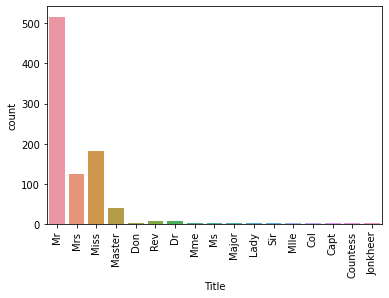

In [5]:
# Split the Title of people and find to replace some titles.
df['Title'] = df.Name.apply(lambda x: re.search(' ([A-Z][a-z]+)\.', x).group(1))
sns.countplot(x='Title', data=df)
plt.xticks(rotation=90);

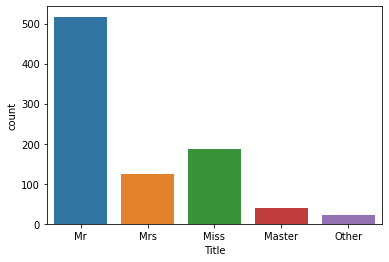

In [6]:
# replace titles
df['Title'] = df['Title'].replace({'Mlle':'Miss','Mme':'Miss','Ms':'Miss'})
df['Title'] = df['Title'].replace(['Don','Rev','Dr','Major','Lady','Sir','Col','Capt','Countess','Jonkheer'],'Other')
sns.countplot(x='Title', data=df);

In [7]:
df['Cabin_Class'] = df.Cabin.str[0]

In [8]:
df['Cabin_Class'].value_counts()

C    59
B    47
D    33
E    32
A    15
F    13
G     4
T     1
Name: Cabin_Class, dtype: int64

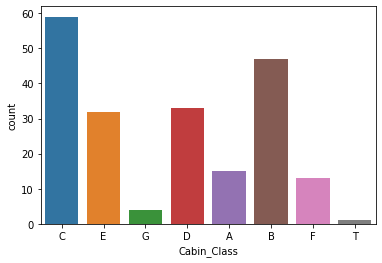

In [9]:
sns.countplot(x='Cabin_Class', data=df);

In [10]:
# Something about Cabins. Has or not?
# df['Has_Cabin'] = ~df.Cabin.isnull()
# sns.countplot(df['Has_Cabin'])
# df.head()

In [11]:
# Drop unused columns
df.drop(['Name','Cabin', 'Ticket'], axis=1, inplace=True)

In [12]:
# View info about preparated dataset. We found vissing values in columns Age and Embarked
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    bool    
 2   Pclass       891 non-null    category
 3   Sex          891 non-null    category
 4   Age          714 non-null    float16 
 5   SibSp        891 non-null    int64   
 6   Parch        891 non-null    int64   
 7   Fare         891 non-null    float64 
 8   Embarked     889 non-null    category
 9   Title        891 non-null    object  
 10  Cabin_Class  204 non-null    object  
dtypes: bool(1), category(3), float16(1), float64(1), int64(3), object(2)
memory usage: 47.5+ KB


In [13]:
# We fill NaN values in the columns
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna('S')
df['Cabin_Class'] = df['Cabin_Class'].fillna(0)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    bool    
 2   Pclass       891 non-null    category
 3   Sex          891 non-null    category
 4   Age          891 non-null    float16 
 5   SibSp        891 non-null    int64   
 6   Parch        891 non-null    int64   
 7   Fare         891 non-null    float64 
 8   Embarked     891 non-null    category
 9   Title        891 non-null    object  
 10  Cabin_Class  891 non-null    object  
dtypes: bool(1), category(3), float16(1), float64(1), int64(3), object(2)
memory usage: 47.5+ KB


# Transform dataset

In [14]:
# Split numerical data to the quantiles
df['Age_cat'] = pd.qcut(df['Age'], q=4, labels=False)
df['Fare_cat'] = pd.qcut(df['Fare'], q=4, labels=False)
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,Cabin_Class,Age_cat,Fare_cat
0,1,False,3,male,22.0,1,0,7.2500,S,Mr,0,0,0
1,2,True,1,female,38.0,1,0,71.2833,C,Mrs,C,3,3
2,3,True,3,female,26.0,0,0,7.9250,S,Miss,0,1,1
3,4,True,1,female,35.0,1,0,53.1000,S,Mrs,C,2,3
4,5,False,3,male,35.0,0,0,8.0500,S,Mr,0,2,1


In [15]:
df.drop(['Age', 'Fare'], axis=1, inplace=True)
df.head()

,PassengerId,Survived,Pclass,Sex,SibSp,Parch,Embarked,Title,Cabin_Class,Age_cat,Fare_cat
0,1,False,3,male,1,0,S,Mr,0,0,0
1,2,True,1,female,1,0,C,Mrs,C,3,3
2,3,True,3,female,0,0,S,Miss,0,1,1
3,4,True,1,female,1,0,S,Mrs,C,2,3
4,5,False,3,male,0,0,S,Mr,0,2,1


In [16]:
# Number of family members on board
df['Family_size'] = df.SibSp + df.Parch
df.head()

,PassengerId,Survived,Pclass,Sex,SibSp,Parch,Embarked,Title,Cabin_Class,Age_cat,Fare_cat,Family_size
0,1,False,3,male,1,0,S,Mr,0,0,0,1
1,2,True,1,female,1,0,C,Mrs,C,3,3,1
2,3,True,3,female,0,0,S,Miss,0,1,1,0
3,4,True,1,female,1,0,S,Mrs,C,2,3,1
4,5,False,3,male,0,0,S,Mr,0,2,1,0


In [17]:
df.drop(['SibSp','Parch'], axis=1)
df.head()

,PassengerId,Survived,Pclass,Sex,SibSp,Parch,Embarked,Title,Cabin_Class,Age_cat,Fare_cat,Family_size
0,1,False,3,male,1,0,S,Mr,0,0,0,1
1,2,True,1,female,1,0,C,Mrs,C,3,3,1
2,3,True,3,female,0,0,S,Miss,0,1,1,0
3,4,True,1,female,1,0,S,Mrs,C,2,3,1
4,5,False,3,male,0,0,S,Mr,0,2,1,0


In [18]:
# Transform variables and category data to numeric data for ML
dff = pd.get_dummies(df, drop_first=True)
dff.head()

,PassengerId,Survived,SibSp,Parch,Age_cat,Fare_cat,Family_size,Pclass_2,Pclass_3,Sex_male,...,Title_Mrs,Title_Other,Cabin_Class_A,Cabin_Class_B,Cabin_Class_C,Cabin_Class_D,Cabin_Class_E,Cabin_Class_F,Cabin_Class_G,Cabin_Class_T
0,1,False,1,0,0,0,1,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,True,1,0,3,3,1,0,0,0,...,1,0,0,0,1,0,0,0,0,0
2,3,True,0,0,1,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,4,True,1,0,2,3,1,0,0,0,...,1,0,0,0,1,0,0,0,0,0
4,5,False,0,0,2,1,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0


# Split dataset to features and target values

In [19]:
#Split dataset to features and target values
X = dff.drop('Survived',axis=1)
y = dff['Survived']

In [20]:
from sklearn import tree
from sklearn.model_selection import GridSearchCV

# Setup parameters
dep = np.arange(1,9)
param_grid = {'max_depth' : dep}

# load a decision tree classifier

clf = tree.DecisionTreeClassifier()

clf_cv = GridSearchCV(clf, param_grid=param_grid,cv=10)

# Fit it to the data

clf_cv.fit(X, y)

print('Tuned Decision Tree Parameters: {}'.format(clf_cv.best_params_))
print('Best score is {}'.format(clf_cv.best_score_))

Tuned Decision Tree Parameters: {'max_depth': 3}
Best score is 0.8305243445692885


# Predict

In [21]:
predict_df = pd.read_csv('/kaggle/input/titanic/test.csv')
predict_df['Sex'] = predict_df['Sex'].astype('category')
predict_df['Pclass'] = predict_df['Pclass'].astype('category')
predict_df['Embarked'] = predict_df['Embarked'].astype('category')
predict_df['Age'] = predict_df['Age'].astype('float16')
predict_df['SibSp'] = predict_df['SibSp'].astype('int64')
predict_df['Title'] = predict_df.Name.apply(lambda x: re.search(' ([A-Z][a-z]+)\.', x).group(1))
predict_df['Title'] = predict_df['Title'].replace({'Mlle':'Miss','Mme':'Miss','Ms':'Miss'})
predict_df['Title'] = predict_df['Title'].replace(['Don','Dona','Rev','Dr','Major','Lady','Sir','Col','Capt','Countess','Jonkheer'],'Other')
predict_df['Cabin_Class'] = predict_df.Cabin.str[0]
predict_df.drop(['Name','Cabin', 'Ticket'], axis=1, inplace=True)
predict_df['Age'] = predict_df['Age'].fillna(predict_df['Age'].median())
predict_df['Embarked'] = predict_df['Embarked'].fillna('S')
predict_df['Cabin_Class'] = df['Cabin_Class'].fillna(0)
predict_df['Fare'] = predict_df['Fare'].fillna(predict_df['Fare'].median())
predict_df['Age_cat'] = pd.qcut(predict_df['Age'], q=4, labels=False)
predict_df['Fare_cat'] = pd.qcut(predict_df['Fare'], q=4, labels=False)
predict_df.drop(['Age', 'Fare'], axis=1, inplace=True)
predict_df['Family_size'] = predict_df.SibSp + predict_df.Parch
predict_df.drop(['SibSp','Parch'], axis=1)
predict_dff = pd.get_dummies(predict_df, drop_first=True)
predict_dff.head()

,PassengerId,SibSp,Parch,Age_cat,Fare_cat,Family_size,Pclass_2,Pclass_3,Sex_male,Embarked_Q,...,Title_Mrs,Title_Other,Cabin_Class_A,Cabin_Class_B,Cabin_Class_C,Cabin_Class_D,Cabin_Class_E,Cabin_Class_F,Cabin_Class_G,Cabin_Class_T
0,892,0,0,2,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,893,1,0,3,0,1,0,1,0,0,...,1,0,0,0,1,0,0,0,0,0
2,894,0,0,3,1,0,1,0,1,1,...,0,0,0,0,0,0,0,0,0,0
3,895,0,0,1,1,0,0,1,1,0,...,0,0,0,0,1,0,0,0,0,0
4,896,1,1,0,1,2,0,1,0,0,...,1,0,0,0,0,0,0,0,0,0


In [22]:
y_predict = clf_cv.predict(predict_dff)
predict_dff['Survived'] = y_predict

In [23]:
predict_dff['PassengerId'] = predict_df['PassengerId']

In [24]:
predict_dff['Survived'] = predict_dff['Survived'].astype(np.int8) 

In [25]:
predict_dff

,PassengerId,SibSp,Parch,Age_cat,Fare_cat,Family_size,Pclass_2,Pclass_3,Sex_male,Embarked_Q,...,Title_Other,Cabin_Class_A,Cabin_Class_B,Cabin_Class_C,Cabin_Class_D,Cabin_Class_E,Cabin_Class_F,Cabin_Class_G,Cabin_Class_T,Survived
0,892,0,0,2,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,893,1,0,3,0,1,0,1,0,0,...,0,0,0,1,0,0,0,0,0,1
2,894,0,0,3,1,0,1,0,1,1,...,0,0,0,0,0,0,0,0,0,0
3,895,0,0,1,1,0,0,1,1,0,...,0,0,0,1,0,0,0,0,0,0
4,896,1,1,0,1,2,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,0,1,1,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
414,1306,0,0,3,3,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
415,1307,0,0,3,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
416,1308,0,0,1,1,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0


In [26]:
predict_dff[['PassengerId', 'Survived']].to_csv('Titanic_passenger_predict.csv', index=False)